# Topik & Identitas



"Analisis Perbandingan Decision Tree, Naïve Bayes, dan K-Nearest Neighbors untuk Klasifikasi Penyakit Jantung"



## Identitas Kelompok

| Nama | NIM |
|------|-----|
| Farel Hagasa Tarigan          | 103032400032 |
| Naza Saputra                  | 1030324
| M.Ataulloh Al Ghafiqi Alvin   | 1030324000
| Andrian Karim                 | 103034

---



# import Library

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("✅ Library berhasil diimport")

✅ Library berhasil diimport


 # Deskripsi dataset, statistik deskriptif, dan sumber data

## 1. Pendahuluan

### 1.1 Latar Belakang

Penyakit jantung merupakan salah satu penyebab kematian tertinggi di dunia 
yang hingga saat ini masih menjadi tantangan serius dalam dunia kesehatan 
global. Menurut World Health Organization (WHO), penyakit kardiovaskular 
menyebabkan sekitar 17,9 juta kematian setiap tahunnya, mewakili 32% dari 
seluruh kematian global. Di Indonesia sendiri, penyakit jantung koroner 
menempati posisi kedua penyebab kematian tertinggi berdasarkan data 
Kementerian Kesehatan Republik Indonesia tahun 2023.

Deteksi dini penyakit jantung menjadi sangat krusial mengingat tingginya 
angka kematian yang sebenarnya dapat dicegah apabila penyakit berhasil 
teridentifikasi sejak stadium awal. Pendekatan tradisional dalam diagnosis 
penyakit jantung seringkali membutuhkan waktu yang lama, biaya yang tinggi, 
serta bergantung penuh pada keahlian dan pengalaman tenaga medis. Kondisi 
ini mendorong perlunya sebuah sistem pendukung keputusan berbasis teknologi 
yang mampu membantu tenaga medis dalam proses diagnosis secara lebih cepat, 
akurat, dan efisien.

Perkembangan teknologi *machine learning* dalam beberapa dekade terakhir 
telah membuka peluang besar dalam bidang kesehatan, khususnya untuk 
keperluan klasifikasi dan prediksi penyakit. Berbagai algoritma *machine 
learning* telah terbukti mampu menganalisis data klinis pasien dan 
menghasilkan prediksi yang akurat dengan waktu komputasi yang jauh lebih 
singkat dibandingkan metode konvensional.

Penelitian ini mengimplementasikan dan membandingkan tiga algoritma 
*machine learning* yang umum digunakan yaitu **Decision Tree**, 
**Naïve Bayes**, dan **K-Nearest Neighbors (KNN)** untuk mengklasifikasikan 
kondisi pasien berdasarkan data klinis. Ketiga algoritma tersebut dioptimasi 
menggunakan **GridSearchCV** dan dievaluasi menggunakan **Stratified K-Fold 
Cross Validation** untuk memastikan hasil yang robust, objektif, dan dapat 
diandalkan. Selain itu, penelitian ini juga menerapkan metode 
interpretabilitas **SHAP (SHapley Additive exPlanations)** pada model 
terbaik untuk menganalisis kontribusi setiap fitur klinis terhadap hasil 
prediksi, sehingga model tidak hanya akurat tetapi juga dapat dijelaskan 
secara medis

---

### 1.2 Rumusan Masalah
Berdasarkan latar belakang yang telah diuraikan, rumusan masalah dalam penelitian ini adalah sebagai berikut:

1. Bagaimana mengimplementasikan algoritma Decision Tree, Naïve Bayes, dan K-Nearest Neighbors (KNN) untuk mengklasifikasikan status penyakit jantung pasien berdasarkan data klinis?

2. Fitur klinis apa saja yang paling berpengaruh terhadap prediksi penyakit jantung berdasarkan analisis interpretabilitas SHAP pada model terbaik?
   

3. Algoritma manakah di antara Decision Tree, Naïve Bayes, dan K-Nearest Neighbors (KNN) yang memberikan performa klasifikasi terbaik dan paling stabil berdasarkan metrik evaluasi Accuracy, Precision, Recall, dan F1-Score?

---

### 1.3 Tujuan Penelitian

1. Mengimplementasikan dan membandingkan tiga algoritma machine  learning yaitu Decision Tree, Naïve Bayes, dan K-Nearest Neighbors untuk klasifikasi penyakit jantung. 
   
2. Mengevaluasi performa ketiga model secara komprehensif menggunakan    metrik Accuracy, Precision, Recall, dan F1-Score.

3. Menganalisis fitur klinis yang paling berpengaruh terhadap prediksi penyakit jantung menggunakan metode interpretabilitas **SHAP** pada  model dengan performa terbaik.
  
   
---

### 1.4 Deskripsi Dataset

Dataset yang digunakan dalam penelitian ini adalah **Heart Disease Dataset**
yang bersumber dari **Kaggle** (Johns Hopkins University / UCI Machine Learning
Repository). Dataset ini berisi rekam medis pasien yang dikumpulkan untuk
keperluan penelitian diagnosis penyakit jantung.

**Informasi Umum Dataset:**

| Keterangan | Detail |
|------------|--------|
| Sumber | [Kaggle — Heart Disease Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset) |
| Jumlah Data | 1.025 baris |
| Jumlah Fitur | 13 fitur input + 1 target |
| Jenis Masalah | Klasifikasi Biner |
| Target | 0 = Tidak Sakit Jantung, 1 = Sakit Jantung |

**Deskripsi Fitur:**

| No | Fitur | Deskripsi | Satuan |
|----|-------|-----------|--------|
| 1 | age | Usia pasien | Tahun |
| 2 | sex | Jenis kelamin | 1=Pria, 0=Wanita |
| 3 | cp | Tipe nyeri dada | 0-3 |
| 4 | trestbps | Tekanan darah saat istirahat | mm Hg |
| 5 | chol | Kolesterol serum | mg/dl |
| 6 | fbs | Gula darah puasa > 120 mg/dl | 1=Ya, 0=Tidak |
| 7 | restecg | Hasil elektrokardiografi | 0-2 |
| 8 | thalach | Detak jantung maksimum | bpm |
| 9 | exang | Angina akibat olahraga | 1=Ya, 0=Tidak |
| 10 | oldpeak | Depresi ST akibat olahraga | Numerik |
| 11 | slope | Kemiringan segmen ST | 0-2 |
| 12 | ca | Jumlah pembuluh darah utama | 0-3 |
| 13 | thal | Thalassemia | 0-3 |
| 14 | target | Diagnosis penyakit jantung | 0=Sehat, 1=Sakit |

In [24]:
# ── Load Dataset ──────────────────────────────────────
df = pd.read_csv('heart.csv')

print("=" * 50)
print("INFORMASI DATASET")
print("=" * 50)
print(f"Jumlah baris    : {df.shape[0]}")
print(f"Jumlah kolom    : {df.shape[1]}")

# Preview data
print("\nPreview 5 Data Pertama:")
display(df.head())

# Statistik Deskriptif
print("\nStatistik Deskriptif:")
display(df.describe().round(2))

# Tipe Data
print("\nTipe Data Setiap Fitur:")
display(df.dtypes.to_frame('Tipe Data'))

# Distribusi Target
print("\nDistribusi Target:")
target_dist = df['target'].value_counts().to_frame('Jumlah')
target_dist['Persentase (%)'] = (
    df['target'].value_counts(normalize=True) * 100
).round(2)
target_dist.index = ['Sakit (1)', 'Sehat (0)']
display(target_dist)

INFORMASI DATASET
Jumlah baris    : 1025
Jumlah kolom    : 14

Preview 5 Data Pertama:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Statistik Deskriptif:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00



Tipe Data Setiap Fitur:


,Tipe Data
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64



Distribusi Target:


,Jumlah,Persentase (%)
Sakit (1),526,51.32
Sehat (0),499,48.68


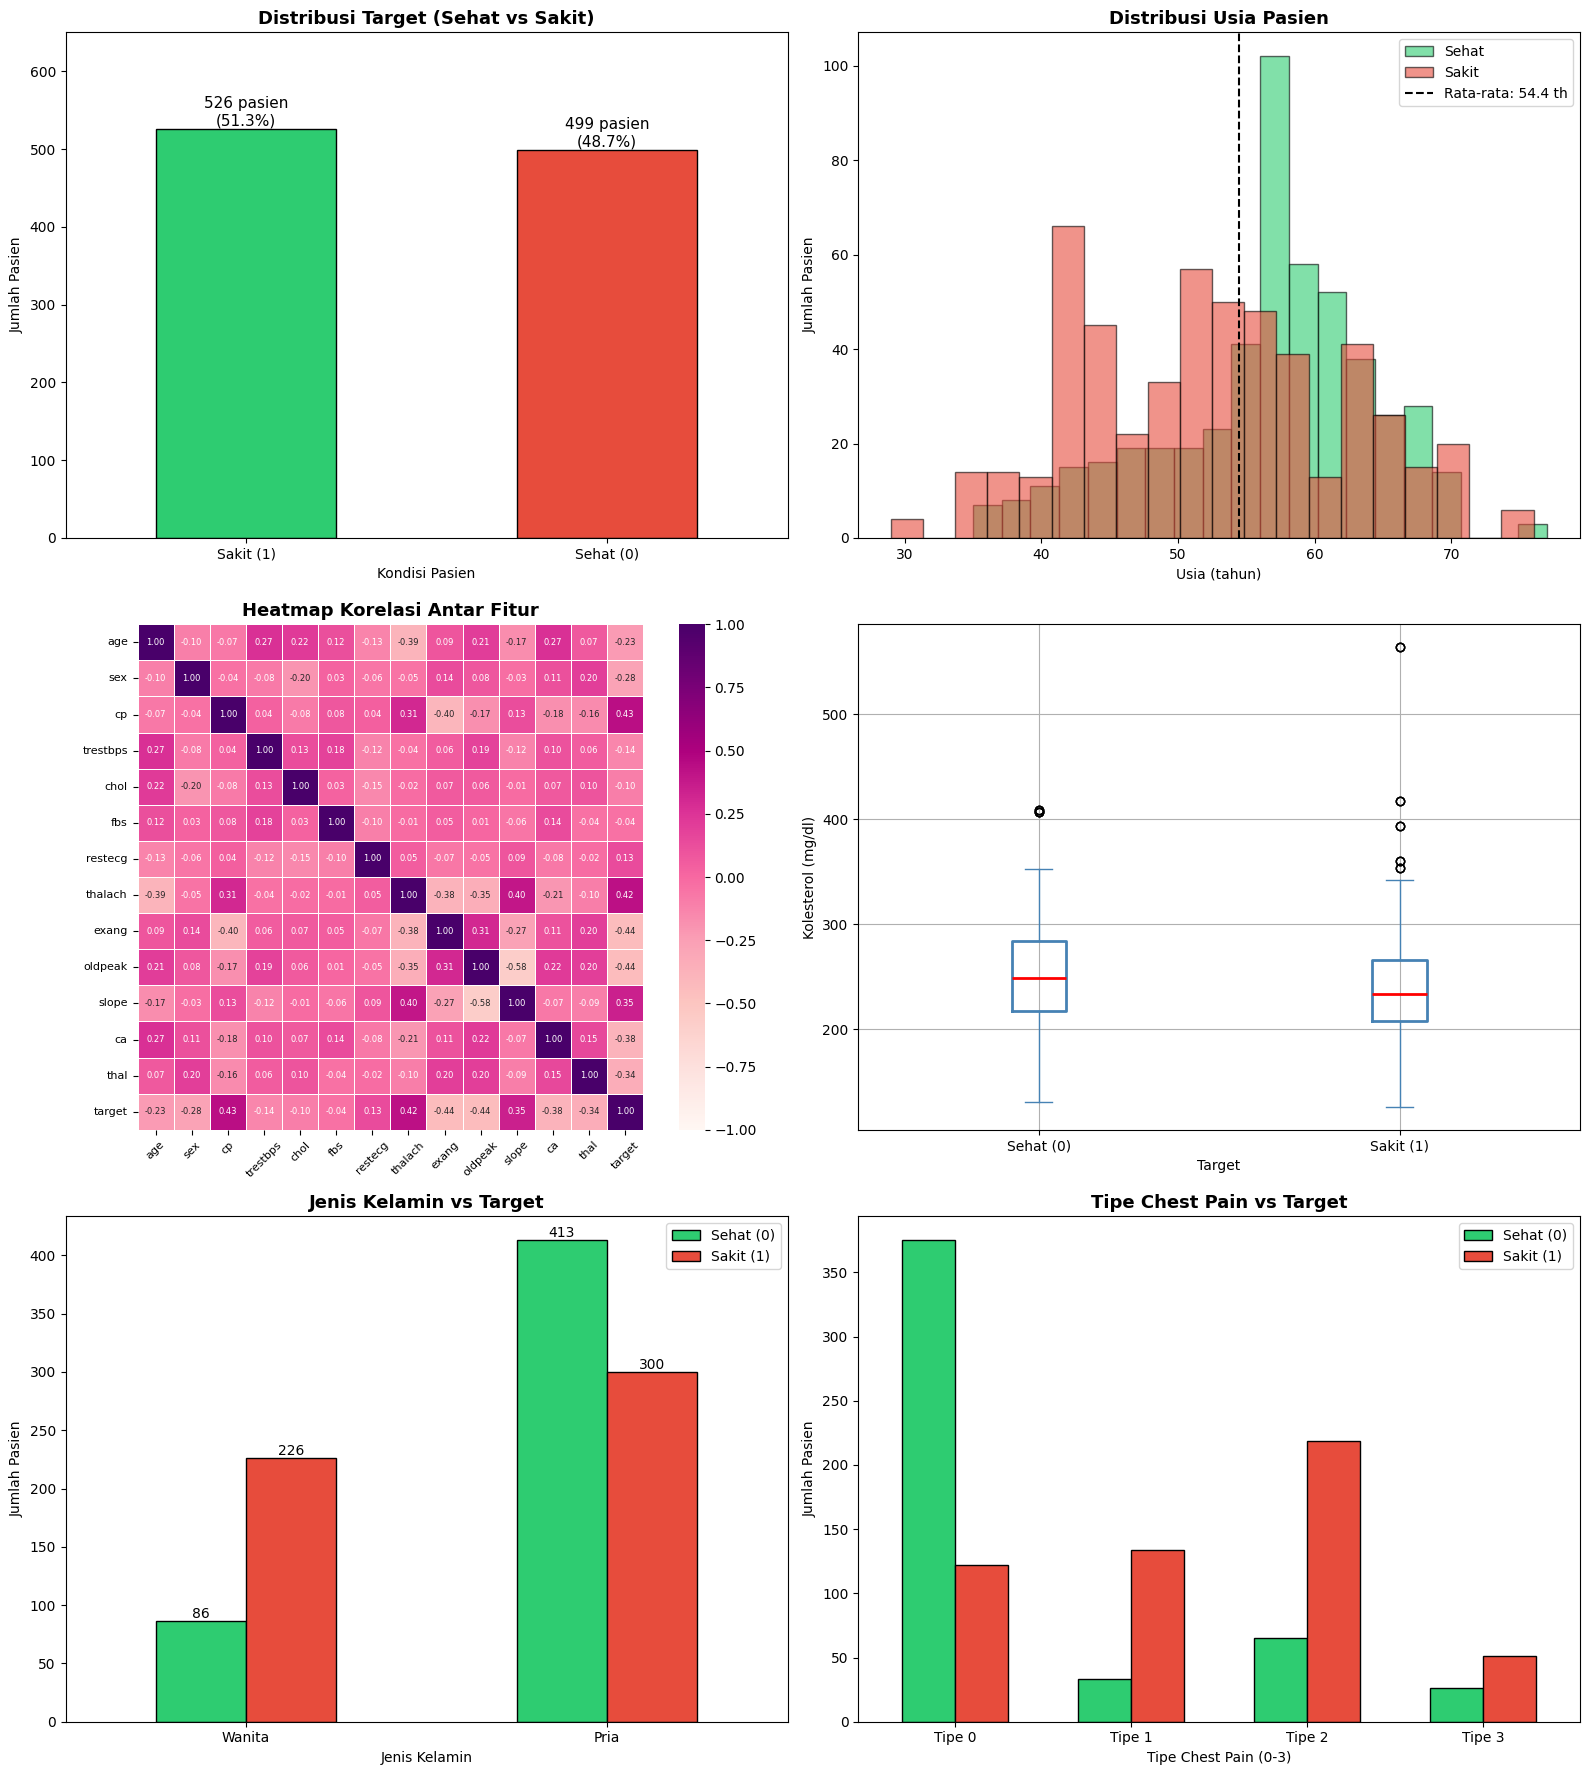

In [25]:
# visualisasi EDA
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Eksplorasi Data - Heart Disease Dataset', 
             fontsize=18, fontweight='bold')

colors = ['#2ecc71', '#e74c3c']

# ── 1. Distribusi Target ──────────────────────────────
ax1 = axes[0, 0]
df['target'].value_counts().plot(kind='bar', ax=ax1, color=colors,
                                  edgecolor='black', width=0.5)
ax1.set_title('Distribusi Target (Sehat vs Sakit)', 
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Kondisi Pasien')
ax1.set_ylabel('Jumlah Pasien')
ax1.set_xticklabels(['Sakit (1)', 'Sehat (0)'], rotation=0)
for p in ax1.patches:
    ax1.annotate(
        f'{int(p.get_height())} pasien\n({p.get_height()/len(df)*100:.1f}%)',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=11)
ax1.set_ylim(0, 650)

# ── 2. Distribusi Usia ────────────────────────────────
ax2 = axes[0, 1]
ax2.hist(df[df['target']==0]['age'], bins=20, alpha=0.6,
         color='#2ecc71', label='Sehat', edgecolor='black')
ax2.hist(df[df['target']==1]['age'], bins=20, alpha=0.6,
         color='#e74c3c', label='Sakit', edgecolor='black')
ax2.axvline(df['age'].mean(), color='black', linestyle='--',
            linewidth=1.5, label=f'Rata-rata: {df["age"].mean():.1f} th')
ax2.set_title('Distribusi Usia Pasien', fontsize=13, fontweight='bold')
ax2.set_xlabel('Usia (tahun)')
ax2.set_ylabel('Jumlah Pasien')
ax2.legend()

# ── 3. Heatmap Korelasi ───────────────────────────────
ax3 = axes[1, 0]
corr = df.corr()
sns.heatmap(corr,
            ax=ax3,
            annot=True,
            fmt='.2f',
            cmap='RdPu',
            vmin=-1, vmax=1,
            linewidths=0.5,
            linecolor='white',
            annot_kws={'size': 6},
            square=True)
ax3.set_title('Heatmap Korelasi Antar Fitur', 
              fontsize=13, fontweight='bold')
ax3.tick_params(axis='x', rotation=45, labelsize=8)
ax3.tick_params(axis='y', rotation=0,  labelsize=8)

# ── 4. Boxplot Kolesterol vs Target ───────────────────
ax4 = axes[1, 1]
df.boxplot(column='chol', by='target', ax=ax4,
           boxprops=dict(color='steelblue', linewidth=2),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='steelblue'),
           capprops=dict(color='steelblue'))
ax4.set_title('Distribusi Kolesterol vs Target', 
              fontsize=13, fontweight='bold')
ax4.set_xlabel('Target')
ax4.set_ylabel('Kolesterol (mg/dl)')
plt.sca(ax4)
plt.xticks([1, 2], ['Sehat (0)', 'Sakit (1)'])
plt.title('')
plt.suptitle('')

# ── 5. Jenis Kelamin vs Target ────────────────────────
ax5 = axes[2, 0]
sex_target = pd.crosstab(df['sex'], df['target'])
sex_target.plot(kind='bar', ax=ax5, color=colors,
                edgecolor='black', width=0.5)
ax5.set_title('Jenis Kelamin vs Target', 
              fontsize=13, fontweight='bold')
ax5.set_xlabel('Jenis Kelamin')
ax5.set_ylabel('Jumlah Pasien')
ax5.legend(['Sehat (0)', 'Sakit (1)'])
ax5.set_xticklabels(['Wanita', 'Pria'], rotation=0)
for p in ax5.patches:
    ax5.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

# ── 6. Chest Pain vs Target ───────────────────────────
ax6 = axes[2, 1]
cp_target = pd.crosstab(df['cp'], df['target'])
cp_target.plot(kind='bar', ax=ax6, color=colors,
               edgecolor='black', width=0.6)
ax6.set_title('Tipe Chest Pain vs Target', 
              fontsize=13, fontweight='bold')
ax6.set_xlabel('Tipe Chest Pain (0-3)')
ax6.set_ylabel('Jumlah Pasien')
ax6.legend(['Sehat (0)', 'Sakit (1)'])
ax6.set_xticklabels(['Tipe 0', 'Tipe 1', 'Tipe 2', 'Tipe 3'], rotation=0)

plt.tight_layout()
plt.show()

# Pra-Pemrosesan Data

## 2. Pra-Pemrosesan Data

Pra-pemrosesan data merupakan tahapan krusial dalam pipeline *machine learning*
yang bertujuan untuk memastikan kualitas data sebelum digunakan dalam proses
pelatihan model. Pada penelitian ini, tahapan pra-pemrosesan meliputi
pengecekan missing values, pengecekan duplikasi data, transformasi fitur,
dan normalisasi data.

---

### 2.1 Pengecekan Missing Values

Missing values atau nilai yang hilang merupakan salah satu permasalahan umum
dalam dataset dunia nyata. Keberadaan missing values dapat menyebabkan bias
pada model apabila tidak ditangani dengan tepat. Pada tahap ini dilakukan
pengecekan terhadap seluruh fitur untuk mengidentifikasi apakah terdapat
nilai yang hilang.

---

### 2.2 Pengecekan Duplikasi Data

Selain missing values, data duplikat juga perlu diidentifikasi dan dihapus
untuk menghindari bias dalam proses pelatihan model. Data duplikat dapat
menyebabkan model menjadi overfit terhadap data yang berulang.

---

### 2.3 Transformasi & Normalisasi Data

Pada penelitian ini, normalisasi data menggunakan **StandardScaler** diterapkan
khusus untuk algoritma **K-Nearest Neighbors (KNN)**. Hal ini dikarenakan KNN
sangat sensitif terhadap perbedaan skala antar fitur — fitur dengan nilai besar
akan mendominasi perhitungan jarak apabila tidak dinormalisasi terlebih dahulu.

Algoritma **Decision Tree** dan **Naïve Bayes** tidak memerlukan normalisasi
karena:
- **Decision Tree** bekerja berdasarkan pemisahan nilai (*threshold*),
  bukan jarak
- **Naïve Bayes** bekerja berdasarkan probabilitas, bukan jarak

Proses normalisasi menggunakan **StandardScaler** dengan rumus:

$$z = \frac{x - \mu}{\sigma}$$

Dimana:
- $x$ = nilai asli fitur
- $\mu$ = rata-rata fitur
- $\sigma$ = standar deviasi fitur
- $z$ = nilai setelah normalisasi

---

### 2.4 Feature Engineering

Pada penelitian ini, *feature engineering* tidak diterapkan secara eksplisit
karena seluruh fitur yang tersedia pada dataset telah merepresentasikan
indikator klinis yang relevan dan informatif untuk klasifikasi penyakit jantung.
Ketigabelas fitur yang ada sudah cukup merepresentasikan kondisi medis pasien
secara komprehensif.

In [26]:
print("=" * 50)
print("PRA-PEMROSESAN DATA")
print("=" * 50)

# ── 1. Cek Missing Values ─────────────────────────────
print("\n1. PENGECEKAN MISSING VALUES")
missing = df.isnull().sum().to_frame('Jumlah Missing')
missing['Persentase (%)'] = (df.isnull().sum() / len(df) * 100).round(2)
missing['Status'] = missing['Jumlah Missing'].apply(
    lambda x: ' Tidak Ada' if x == 0 else ' Ada Missing'
)
display(missing)

# ── 2. Cek Duplikasi ──────────────────────────────────
print("\n2. PENGECEKAN DUPLIKASI DATA")
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah data duplikat : {jumlah_duplikat}")
if jumlah_duplikat > 0:
    df = df.drop_duplicates()
    print(f" Duplikat dihapus, sisa data: {len(df)}")
else:
    print(" Tidak ada data duplikat")

# ── 3. Pisahkan Fitur & Target ────────────────────────
print("\n3. PEMISAHAN FITUR DAN TARGET")
X = df.drop('target', axis=1)
y = df['target']
print(f"Fitur (X) shape : {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Fitur yang digunakan:")
display(pd.DataFrame({
    'Fitur': X.columns,
    'Tipe' : X.dtypes.values
}))

# ── 4. Setup Cross Validation ─────────────────────────
print("\n4. SETUP CROSS VALIDATION")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(" Stratified K-Fold: 5 splits, random_state=42")

print("\n Pra-Pemrosesan selesai!")

PRA-PEMROSESAN DATA

1. PENGECEKAN MISSING VALUES


,Jumlah Missing,Persentase (%),Status
age,0,0.0,Tidak Ada
sex,0,0.0,Tidak Ada
cp,0,0.0,Tidak Ada
trestbps,0,0.0,Tidak Ada
chol,0,0.0,Tidak Ada
fbs,0,0.0,Tidak Ada
restecg,0,0.0,Tidak Ada
thalach,0,0.0,Tidak Ada
exang,0,0.0,Tidak Ada
oldpeak,0,0.0,Tidak Ada



2. PENGECEKAN DUPLIKASI DATA
Jumlah data duplikat : 723
 Duplikat dihapus, sisa data: 302

3. PEMISAHAN FITUR DAN TARGET
Fitur (X) shape : (302, 13)
Target (y) shape: (302,)
Fitur yang digunakan:


,Fitur,Tipe
0,age,int64
1,sex,int64
2,cp,int64
3,trestbps,int64
4,chol,int64
5,fbs,int64
6,restecg,int64
7,thalach,int64
8,exang,int64
9,oldpeak,float64



4. SETUP CROSS VALIDATION
 Stratified K-Fold: 5 splits, random_state=42

 Pra-Pemrosesan selesai!


## 3. Penanganan Imbalanced Data

Imbalanced data terjadi ketika jumlah data pada setiap kelas target tidak
seimbang secara signifikan. Kondisi ini dapat menyebabkan model cenderung
memprediksi kelas mayoritas dan mengabaikan kelas minoritas, sehingga
menghasilkan performa yang bias.

---

### 3.1 Identifikasi Ketidakseimbangan Data

Sebelum menerapkan teknik penanganan, perlu dilakukan identifikasi terlebih
dahulu apakah dataset yang digunakan mengalami ketidakseimbangan kelas.
Umumnya dataset dikatakan tidak seimbang apabila rasio antar kelas melebihi
**10%**.

---

### 3.2 Teknik Penanganan Imbalanced Data

Terdapat beberapa teknik yang umum digunakan untuk menangani imbalanced data:

| Teknik | Cara Kerja | Kelebihan | Kekurangan |
|--------|-----------|-----------|------------|
| **SMOTE** | Membuat data sintetis pada kelas minoritas | Tidak membuang data | Bisa menghasilkan data noise |
| **Undersampling** | Mengurangi data kelas mayoritas | Simpel | Kehilangan informasi penting |
| **Class Weighting** | Memberi bobot lebih pada kelas minoritas | Tidak mengubah data asli | Tidak selalu efektif |
| **Stratified K-Fold** | Menjaga proporsi kelas di setiap fold | Evaluasi lebih adil | Bukan teknik resampling |

---

### 3.3 Strategi yang Diterapkan

Berdasarkan hasil analisis distribusi kelas pada dataset Heart Disease,
ditemukan bahwa:

- Kelas **Sakit (1)** : 526 data (51.32%)
- Kelas **Sehat (0)** : 499 data (48.68%)
- Selisih proporsi    : 2.64%

Karena selisih proporsi antar kelas **kurang dari 10%**, dataset ini
dikategorikan sebagai **seimbang (balanced)**. Oleh karena itu, teknik
resampling seperti SMOTE atau undersampling **tidak diperlukan**.

Strategi yang diterapkan dalam penelitian ini adalah penggunaan
**Stratified K-Fold Cross Validation** yang secara otomatis menjaga
proporsi kelas di setiap fold sehingga proses pelatihan dan evaluasi
model tetap representatif dan tidak bias.

PENANGANAN IMBALANCED DATA

Kelas 0 (Sehat) : 138 data (45.70%)
Kelas 1 (Sakit) : 164 data (54.30%)
Selisih Proporsi: 8.61%
Rasio Imbalance : 1.19:1

 Dataset SEIMBANG (selisih < 10%)
→ Teknik SMOTE/undersampling tidak diperlukan
→ Strategi: Stratified K-Fold Cross Validation


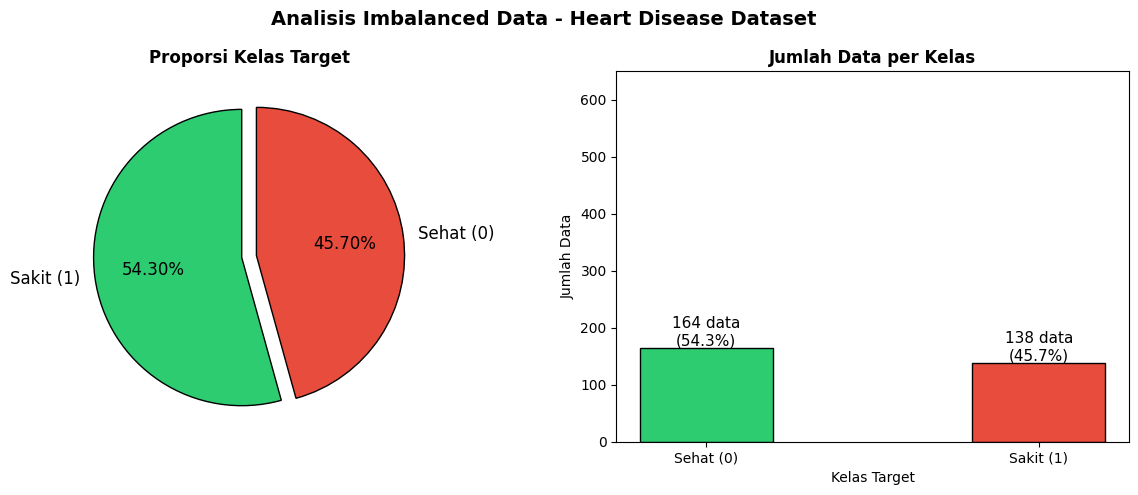

In [27]:
print("=" * 50)
print("PENANGANAN IMBALANCED DATA")
print("=" * 50)

# ── Hitung Distribusi Kelas ───────────────────────────
kelas = y.value_counts()
rasio = y.value_counts(normalize=True) * 100
selisih = abs(rasio[0] - rasio[1])

print(f"\nKelas 0 (Sehat) : {kelas[0]} data ({rasio[0]:.2f}%)")
print(f"Kelas 1 (Sakit) : {kelas[1]} data ({rasio[1]:.2f}%)")
print(f"Selisih Proporsi: {selisih:.2f}%")
print(f"Rasio Imbalance : {kelas.max()/kelas.min():.2f}:1")

if selisih < 10:
    print("\n Dataset SEIMBANG (selisih < 10%)")
    print("→ Teknik SMOTE/undersampling tidak diperlukan")
    print("→ Strategi: Stratified K-Fold Cross Validation")
else:
    print("\nS Dataset TIDAK SEIMBANG (selisih > 10%)")
    print("→ Diperlukan teknik resampling")

# ── Visualisasi ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Analisis Imbalanced Data - Heart Disease Dataset',
             fontsize=14, fontweight='bold')

colors = ['#2ecc71', '#e74c3c']

# Pie Chart
ax1 = axes[0]
ax1.pie(kelas, labels=['Sakit (1)', 'Sehat (0)'],
        colors=colors, autopct='%1.2f%%',
        startangle=90, explode=(0.05, 0.05),
        textprops={'fontsize': 12},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})
ax1.set_title('Proporsi Kelas Target', 
              fontsize=12, fontweight='bold')

# Bar Chart
ax2 = axes[1]
bars = ax2.bar(['Sehat (0)', 'Sakit (1)'], 
               kelas.values,
               color=colors, edgecolor='black', width=0.4)
ax2.set_title('Jumlah Data per Kelas', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Kelas Target')
ax2.set_ylabel('Jumlah Data')
ax2.set_ylim(0, 650)
for bar in bars:
    ax2.annotate(
        f'{int(bar.get_height())} data\n({bar.get_height()/len(y)*100:.1f}%)',
        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

## 4. Metode & Eksperimen

### 4.1 Penjelasan Konsep Algoritma

#### 4.1.1 Naïve Bayes

Naïve Bayes adalah algoritma klasifikasi berbasis probabilitas yang menerapkan
**Teorema Bayes** dengan asumsi independensi antar fitur. Algoritma ini disebut
"naïve" karena mengasumsikan setiap fitur tidak saling mempengaruhi satu sama
lain, meskipun dalam kenyataannya hal tersebut tidak selalu terpenuhi.

Rumus dasar Teorema Bayes:

$$P(C|X) = \frac{P(X|C) \times P(C)}{P(X)}$$

Dimana:
- $P(C|X)$ = probabilitas kelas $C$ given fitur $X$ (posterior)
- $P(X|C)$ = probabilitas fitur $X$ given kelas $C$ (likelihood)
- $P(C)$   = probabilitas kelas $C$ secara umum (prior)
- $P(X)$   = probabilitas fitur $X$ (evidence)

Pada penelitian ini digunakan **Gaussian Naïve Bayes** karena fitur-fitur
dalam dataset bersifat kontinu dan diasumsikan mengikuti distribusi normal.

---

#### 4.1.2 Decision Tree

Decision Tree adalah algoritma klasifikasi yang bekerja dengan membagi data
secara rekursif berdasarkan fitur yang paling informatif. Struktur modelnya
menyerupai pohon keputusan dengan node, cabang, dan daun.

Proses pemilihan fitur terbaik menggunakan kriteria:

**Gini Impurity:**
$$Gini = 1 - \sum_{i=1}^{n} p_i^2$$

**Entropy:**
$$Entropy = -\sum_{i=1}^{n} p_i \log_2(p_i)$$

Dimana $p_i$ adalah proporsi kelas $i$ pada node tersebut. Fitur dengan
nilai Gini atau Entropy terendah dipilih sebagai pemisah terbaik.

---

#### 4.1.3 K-Nearest Neighbors (KNN)

K-Nearest Neighbors adalah algoritma klasifikasi berbasis instance yang
memprediksi kelas suatu data baru berdasarkan **k tetangga terdekat** dalam
ruang fitur. Algoritma ini tidak membangun model secara eksplisit, melainkan
menyimpan seluruh data training.

Perhitungan jarak menggunakan **Euclidean Distance**:

$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

KNN sangat sensitif terhadap skala fitur, sehingga **normalisasi wajib
diterapkan** sebelum pelatihan model menggunakan StandardScaler.

---

### 4.2 Cross Validation & Hyperparameter Tuning

Pada penelitian ini digunakan **Stratified K-Fold Cross Validation** dengan
$k=5$ untuk memastikan setiap fold memiliki proporsi kelas yang representatif.
Proses optimasi hyperparameter dilakukan menggunakan **GridSearchCV** yang
mencoba seluruh kombinasi parameter secara sistematis.

Metrik evaluasi yang digunakan:

| Metrik | Rumus | Keterangan |
|--------|-------|------------|
| **Accuracy** | $\frac{TP+TN}{TP+TN+FP+FN}$ | Proporsi prediksi benar |
| **Precision** | $\frac{TP}{TP+FP}$ | Ketepatan prediksi positif |
| **Recall** | $\frac{TP}{TP+FN}$ | Kemampuan deteksi positif |
| **F1-Score** | $\frac{2 \times Precision \times Recall}{Precision+Recall}$ | Keseimbangan precision & recall |

Pada konteks medis, **Recall** menjadi metrik paling kritis karena lebih
berbahaya melewatkan pasien sakit (False Negative) daripada salah mendeteksi
pasien sehat sebagai sakit (False Positive).

---

### 4.3 Interpretability AI — SHAP

**SHAP (SHapley Additive exPlanations)** adalah metode interpretasi model
yang menjelaskan kontribusi setiap fitur terhadap hasil prediksi. SHAP
diterapkan pada model terbaik untuk menjawab pertanyaan:

> *"Fitur mana yang paling berpengaruh dalam prediksi penyakit jantung?"*

SHAP value positif → fitur mendorong prediksi ke arah **Sakit**

SHAP value negatif → fitur mendorong prediksi ke arah **Sehat**

In [28]:
print("=" * 50)
print("MODEL 1: NAÏVE BAYES")
print("=" * 50)

# ── Pipeline & GridSearchCV ───────────────────────────
nb_pipeline = Pipeline([('clf', GaussianNB())])

nb_params = {
    'clf__var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

nb_grid = GridSearchCV(nb_pipeline, nb_params, cv=cv,
                       scoring='accuracy', n_jobs=-1)
nb_grid.fit(X, y)

print(f"Best Parameters : {nb_grid.best_params_}")
print(f"Best CV Accuracy: {nb_grid.best_score_:.4f}")

# ── Prediksi ──────────────────────────────────────────
nb_best  = nb_grid.best_estimator_
nb_pred  = cross_val_predict(nb_best, X, y, cv=cv)
nb_proba = cross_val_predict(nb_best, X, y, cv=cv, method='predict_proba')

# ── Evaluasi ──────────────────────────────────────────
print("\n=== Classification Report ===")
print(classification_report(y, nb_pred, target_names=['Sehat', 'Sakit']))

# ── Tabel Metrik ──────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score
nb_metrics = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score' : [
        accuracy_score(y, nb_pred),
        precision_score(y, nb_pred),
        recall_score(y, nb_pred),
        f1_score(y, nb_pred)
    ]
})
nb_metrics['Score'] = nb_metrics['Score'].round(4)
print("\nRingkasan Metrik Naïve Bayes:")
display(nb_metrics)

MODEL 1: NAÏVE BAYES
Best Parameters : {'clf__var_smoothing': 1e-05}
Best CV Accuracy: 0.8180

=== Classification Report ===
              precision    recall  f1-score   support

       Sehat       0.83      0.76      0.79       138
       Sakit       0.81      0.87      0.84       164

    accuracy                           0.82       302
   macro avg       0.82      0.81      0.82       302
weighted avg       0.82      0.82      0.82       302


Ringkasan Metrik Naïve Bayes:


,Metrik,Score
0,Accuracy,0.8179
1,Precision,0.8114
2,Recall,0.8659
3,F1-Score,0.8378


In [29]:
print("=" * 50)
print("MODEL 2: DECISION TREE")
print("=" * 50)

# ── Pipeline & GridSearchCV ───────────────────────────
dt_pipeline = Pipeline([
    ('clf', DecisionTreeClassifier(random_state=42))
])

dt_params = {
    'clf__max_depth'        : [3, 5, 7, 10, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf' : [1, 2, 4],
    'clf__criterion'        : ['gini', 'entropy']
}

dt_grid = GridSearchCV(dt_pipeline, dt_params, cv=cv,
                       scoring='accuracy', n_jobs=-1)
dt_grid.fit(X, y)

print(f" Best Parameters : {dt_grid.best_params_}")
print(f" Best CV Accuracy: {dt_grid.best_score_:.4f}")

# ── Prediksi ──────────────────────────────────────────
dt_best  = dt_grid.best_estimator_
dt_pred  = cross_val_predict(dt_best, X, y, cv=cv)
dt_proba = cross_val_predict(dt_best, X, y, cv=cv, method='predict_proba')

# ── Evaluasi ──────────────────────────────────────────
print("\n=== Classification Report ===")
print(classification_report(y, dt_pred, target_names=['Sehat', 'Sakit']))

# ── Tabel Metrik ──────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score
dt_metrics = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score' : [
        accuracy_score(y, dt_pred),
        precision_score(y, dt_pred),
        recall_score(y, dt_pred),
        f1_score(y, dt_pred)
    ]
})
dt_metrics['Score'] = dt_metrics['Score'].round(4)
print("\nRingkasan Metrik Decision Tree:")
display(dt_metrics)

MODEL 2: DECISION TREE
 Best Parameters : {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2}
 Best CV Accuracy: 0.7846

=== Classification Report ===
              precision    recall  f1-score   support

       Sehat       0.79      0.72      0.75       138
       Sakit       0.78      0.84      0.81       164

    accuracy                           0.78       302
   macro avg       0.79      0.78      0.78       302
weighted avg       0.78      0.78      0.78       302


Ringkasan Metrik Decision Tree:


,Metrik,Score
0,Accuracy,0.7848
1,Precision,0.7829
2,Recall,0.8354
3,F1-Score,0.8083


In [30]:
print("=" * 50)
print("MODEL 3: K-NEAREST NEIGHBORS")
print("=" * 50)

# ── Pipeline & GridSearchCV ───────────────────────────
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier())
])

knn_params = {
    'clf__n_neighbors': [3, 5, 7, 9, 11, 15],
    'clf__weights'    : ['uniform', 'distance'],
    'clf__metric'     : ['euclidean', 'manhattan', 'minkowski']
}

knn_grid = GridSearchCV(knn_pipeline, knn_params, cv=cv,
                        scoring='accuracy', n_jobs=-1)
knn_grid.fit(X, y)

print(f" Best Parameters : {knn_grid.best_params_}")
print(f" Best CV Accuracy: {knn_grid.best_score_:.4f}")

# ── Prediksi ──────────────────────────────────────────
knn_best  = knn_grid.best_estimator_
knn_pred  = cross_val_predict(knn_best, X, y, cv=cv)
knn_proba = cross_val_predict(knn_best, X, y, cv=cv, method='predict_proba')

# ── Evaluasi ──────────────────────────────────────────
print("\n=== Classification Report ===")
print(classification_report(y, knn_pred, target_names=['Sehat', 'Sakit']))

# ── Tabel Metrik ──────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score
knn_metrics = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score' : [
        accuracy_score(y, knn_pred),
        precision_score(y, knn_pred),
        recall_score(y, knn_pred),
        f1_score(y, knn_pred)
    ]
})
knn_metrics['Score'] = knn_metrics['Score'].round(4)
print("\nRingkasan Metrik KNN:")
display(knn_metrics)

MODEL 3: K-NEAREST NEIGHBORS


 Best Parameters : {'clf__metric': 'euclidean', 'clf__n_neighbors': 15, 'clf__weights': 'uniform'}
 Best CV Accuracy: 0.8413

=== Classification Report ===
              precision    recall  f1-score   support

       Sehat       0.89      0.75      0.81       138
       Sakit       0.81      0.92      0.86       164

    accuracy                           0.84       302
   macro avg       0.85      0.83      0.84       302
weighted avg       0.85      0.84      0.84       302


Ringkasan Metrik KNN:


,Metrik,Score
0,Accuracy,0.8411
1,Precision,0.8118
2,Recall,0.9207
3,F1-Score,0.8629


In [31]:
import shap
import warnings
warnings.filterwarnings('ignore')

print("=" * 50)
print("INTERPRETABILITY AI — SHAP")
print("=" * 50)

# ── 1. Train ulang KNN dengan data penuh ──


knn_final = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(
        n_neighbors = 15,
        weights     = 'uniform',
        metric      = 'euclidean'
    ))
])
knn_final.fit(X, y)
print(" Model KNN berhasil di-train ulang")

# ── 2. Transform data pakai scaler dari pipeline ──────
X_scaled = pd.DataFrame(
    knn_final.named_steps['scaler'].transform(X),
    columns=X.columns
)
print(" Data berhasil di-scale")

# ── 3. Buat SHAP Explainer ────────────────────────────
explainer = shap.KernelExplainer(
    knn_final.named_steps['clf'].predict_proba,
    shap.sample(X_scaled, 50),  
    link='identity'
)
print(" SHAP Explainer berhasil dibuat")

# ── 4. Hitung SHAP Values ─────────────────────────────
print("\n Menghitung SHAP values (mohon tunggu)...")
shap_values = explainer.shap_values(
    shap.sample(X_scaled, 100)
)
print(" SHAP values berhasil dihitung")

INTERPRETABILITY AI — SHAP
 Model KNN berhasil di-train ulang
 Data berhasil di-scale
 SHAP Explainer berhasil dibuat

 Menghitung SHAP values (mohon tunggu)...


100%|██████████| 100/100 [03:12<00:00,  1.93s/it]

 SHAP values berhasil dihitung


Shape shap_values_array: (100, 13, 2)
Shape shap_vals_sakit  : (100, 13)

SHAP - FITUR PALING BERPENGARUH


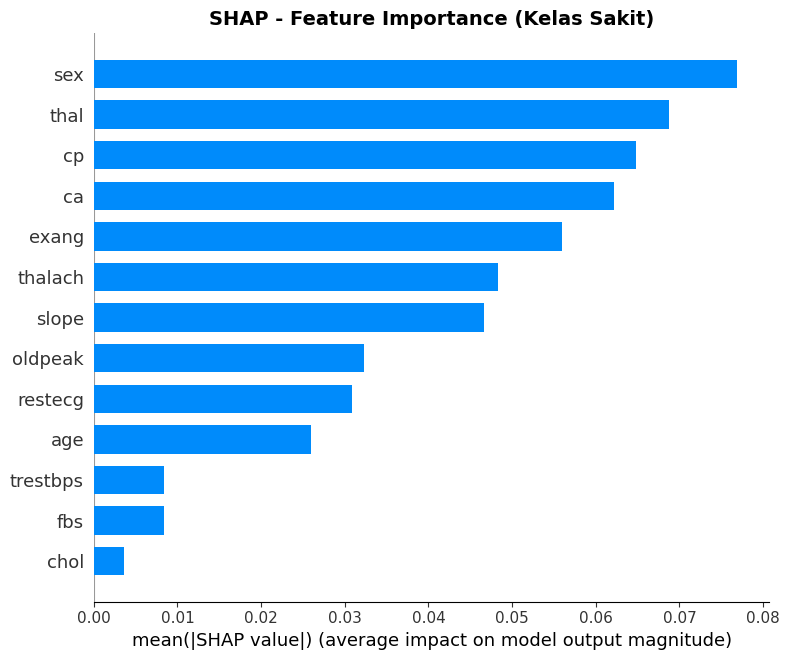


Rata-rata SHAP Value per Fitur:


,Fitur,Rata-rata |SHAP|
1,sex,0.0769
2,thal,0.0688
3,cp,0.0648
4,ca,0.0622
5,exang,0.0559
6,thalach,0.0483
7,slope,0.0466
8,oldpeak,0.0323
9,restecg,0.0309
10,age,0.0260


In [32]:
# ── 5.  Shape SHAP Values ──────────────────────────
shap_values_array = np.array(shap_values)
shap_vals_sakit = shap_values_array[:, :, 1]
print("Shape shap_values_array:", shap_values_array.shape)
print("Shape shap_vals_sakit  :", shap_vals_sakit.shape)

X_sample = shap.sample(X_scaled, 100)

# ── 6. Summary Plot Bar ───────────────────────────────
print("\n" + "=" * 50)
print("SHAP - FITUR PALING BERPENGARUH")
print("=" * 50)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_vals_sakit,
    X_sample,
    plot_type='bar',
    feature_names=X.columns.tolist(),
    show=False
)
plt.title('SHAP - Feature Importance (Kelas Sakit)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



# ── 8. Tabel SHAP Values ──────────────────────────────
print("\nRata-rata SHAP Value per Fitur:")
shap_df = pd.DataFrame({
    'Fitur'           : X.columns.tolist(),
    'Rata-rata |SHAP|': np.abs(shap_vals_sakit).mean(axis=0)
}).sort_values('Rata-rata |SHAP|', ascending=False).reset_index(drop=True)
shap_df.index += 1
display(shap_df.round(4))

## 5. Hasil & Analisis

Pada bagian ini disajikan hasil evaluasi performa ketiga model yang telah 
diimplementasikan beserta analisis mendalam terhadap kesalahan prediksi 
masing-masing model. Evaluasi dilakukan menggunakan metrik yang relevan 
dengan konteks permasalahan medis, yaitu Accuracy, Precision, Recall, 
dan F1-Score.

---

### 5.1 Evaluasi Kinerja Model

Evaluasi kinerja model dilakukan menggunakan **Stratified K-Fold Cross 
Validation** dengan k=5 untuk memastikan hasil evaluasi yang objektif 
dan tidak bias. Metrik utama yang digunakan adalah **Recall** karena 
dalam konteks medis, kesalahan melewatkan pasien sakit (*False Negative*) 
jauh lebih berbahaya dibandingkan kesalahan mendeteksi pasien sehat 
sebagai sakit (*False Positive*).

---

### 5.2 Analisis Confusion Matrix

Confusion Matrix digunakan untuk menganalisis secara detail hasil prediksi 
setiap model. Melalui Confusion Matrix dapat diidentifikasi jumlah prediksi 
benar (*True Positive* dan *True Negative*) serta prediksi salah 
(*False Positive* dan *False Negative*) dari masing-masing model.

---

### 5.3 Analisis Confidence

Analisis confidence dilakukan untuk mengukur seberapa yakin model dalam 
membuat prediksi. Model yang baik seharusnya memiliki:

- **Confidence tinggi** saat prediksinya **benar** ✅
- **Confidence rendah** saat prediksinya **salah** ✅

Apabila model salah prediksi namun confidence-nya tinggi (*overconfident*), 
hal ini berbahaya dalam konteks medis karena tenaga medis dapat terlalu 
mempercayai hasil prediksi yang salah tersebut.

In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("=" * 55)
print("HASIL & ANALISIS — EVALUASI KINERJA MODEL")
print("=" * 55)

# ── Tabel Perbandingan Semua Model ────────────────────
results = pd.DataFrame({
    'Model': ['Naïve Bayes', 'Decision Tree', 'KNN'],
    'CV Accuracy': [
        nb_grid.best_score_,
        dt_grid.best_score_,
        knn_grid.best_score_
    ],
    'Accuracy': [
        accuracy_score(y, nb_pred),
        accuracy_score(y, dt_pred),
        accuracy_score(y, knn_pred)
    ],
    'Precision': [
        precision_score(y, nb_pred),
        precision_score(y, dt_pred),
        precision_score(y, knn_pred)
    ],
    'Recall': [
        recall_score(y, nb_pred),
        recall_score(y, dt_pred),
        recall_score(y, knn_pred)
    ],
    'F1-Score': [
        f1_score(y, nb_pred),
        f1_score(y, dt_pred),
        f1_score(y, knn_pred)
    ]
})

results = results.sort_values('F1-Score', 
                               ascending=False).reset_index(drop=True)
results.index += 1

print("\nTabel Perbandingan Performa Model:")
display(results.round(4))

# ── Identifikasi Model Terbaik ────────────────────────
best_model = results.iloc[0]['Model']
best_f1    = results.iloc[0]['F1-Score']
best_recall= results.iloc[0]['Recall']
print(f"\n Model Terbaik : {best_model}")
print(f"   F1-Score      : {best_f1:.4f}")
print(f"   Recall        : {best_recall:.4f}")

HASIL & ANALISIS — EVALUASI KINERJA MODEL

Tabel Perbandingan Performa Model:


,Model,CV Accuracy,Accuracy,Precision,Recall,F1-Score
1,KNN,0.8413,0.8411,0.8118,0.9207,0.8629
2,Naïve Bayes,0.8180,0.8179,0.8114,0.8659,0.8378
3,Decision Tree,0.7846,0.7848,0.7829,0.8354,0.8083



 Model Terbaik : KNN
   F1-Score      : 0.8629
   Recall        : 0.9207


CONFUSION MATRIX — SEMUA MODEL


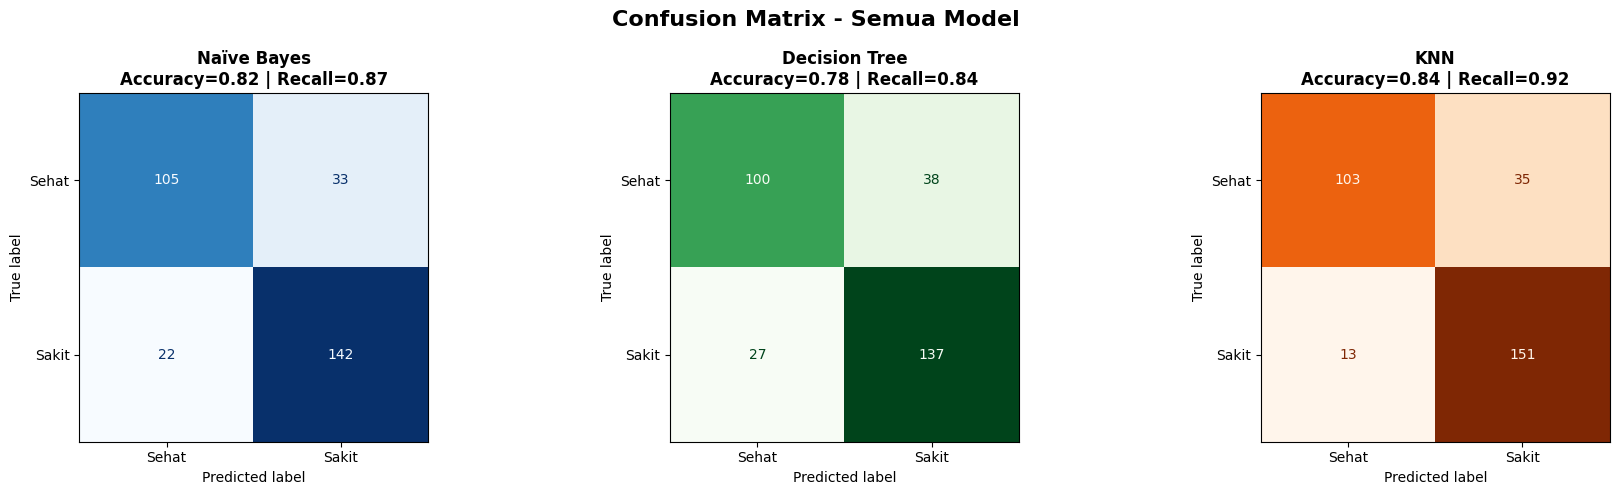


=== ANALISIS CONFUSION MATRIX ===

 Naïve Bayes
   True Negative  (TN) : 105  → Sehat diprediksi Sehat 
   True Positive  (TP) : 142  → Sakit diprediksi Sakit 
   False Positive (FP) : 33  → Sehat diprediksi Sakit 
   False Negative (FN) : 22  → Sakit diprediksi Sehat 
   → Pasien sakit tidak terdeteksi: 22 orang

 Decision Tree
   True Negative  (TN) : 100  → Sehat diprediksi Sehat 
   True Positive  (TP) : 137  → Sakit diprediksi Sakit 
   False Positive (FP) : 38  → Sehat diprediksi Sakit 
   False Negative (FN) : 27  → Sakit diprediksi Sehat 
   → Pasien sakit tidak terdeteksi: 27 orang

 KNN
   True Negative  (TN) : 103  → Sehat diprediksi Sehat 
   True Positive  (TP) : 151  → Sakit diprediksi Sakit 
   False Positive (FP) : 35  → Sehat diprediksi Sakit 
   False Negative (FN) : 13  → Sakit diprediksi Sehat 
   → Pasien sakit tidak terdeteksi: 13 orang



In [34]:
print("=" * 55)
print("CONFUSION MATRIX — SEMUA MODEL")
print("=" * 55)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix - Semua Model', 
             fontsize=16, fontweight='bold')

models_cm = [
    (nb_pred,  nb_proba,  'Naïve Bayes',   'Blues'),
    (dt_pred,  dt_proba,  'Decision Tree',  'Greens'),
    (knn_pred, knn_proba, 'KNN',            'Oranges')
]

for ax, (pred, proba, title, cmap) in zip(axes, models_cm):
    cm = confusion_matrix(y, pred)
    
    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Sehat', 'Sakit'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    
    # Hitung metrik
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y, pred)
    rec = recall_score(y, pred)
    
    ax.set_title(f'{title}\nAccuracy={acc:.2f} | Recall={rec:.2f}', 
                 fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Analisis Per Model ────────────────────────────────
print("\n=== ANALISIS CONFUSION MATRIX ===\n")

for pred, proba, title in [
    (nb_pred,  nb_proba,  'Naïve Bayes'),
    (dt_pred,  dt_proba,  'Decision Tree'),
    (knn_pred, knn_proba, 'KNN')
]:
    cm = confusion_matrix(y, pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f" {title}")
    print(f"   True Negative  (TN) : {tn}  → Sehat diprediksi Sehat ")
    print(f"   True Positive  (TP) : {tp}  → Sakit diprediksi Sakit ")
    print(f"   False Positive (FP) : {fp}  → Sehat diprediksi Sakit ")
    print(f"   False Negative (FN) : {fn}  → Sakit diprediksi Sehat ")
    print(f"   → Pasien sakit tidak terdeteksi: {fn} orang")
    print()

In [35]:
print("=" * 55)
print("CONFIDENCE ANALYSIS — SEMUA MODEL")
print("=" * 55)

# ── Fungsi Confidence Analysis ────────────────────────
def confidence_analysis(y_true, y_pred, y_proba, model_name):
    confidence = y_proba.max(axis=1)
    correct    = (y_true.values == y_pred)
    wrong      = ~correct
    
    avg_conf_correct = confidence[correct].mean()
    avg_conf_wrong   = confidence[wrong].mean()
    
    print(f"\n {model_name}")
    print(f"   Total prediksi BENAR : {correct.sum()} data")
    print(f"   Total prediksi SALAH : {wrong.sum()} data")
    print(f"   Avg confidence BENAR : {avg_conf_correct:.4f} ({avg_conf_correct*100:.2f}%)")
    print(f"   Avg confidence SALAH : {avg_conf_wrong:.4f} ({avg_conf_wrong*100:.2f}%)")
    print(f"   Selisih              : {(avg_conf_correct - avg_conf_wrong):.4f}")
    
    # Cek overconfident
    if avg_conf_wrong > 0.75:
        print(f"    Model OVERCONFIDENT saat salah prediksi!")
    else:
        print(f"    Model tidak overconfident")
    
    return avg_conf_correct, avg_conf_wrong

nb_cc,  nb_cw  = confidence_analysis(y, nb_pred,  nb_proba,  "Naïve Bayes")
dt_cc,  dt_cw  = confidence_analysis(y, dt_pred,  dt_proba,  "Decision Tree")
knn_cc, knn_cw = confidence_analysis(y, knn_pred, knn_proba, "KNN")

# ── Tabel Ringkasan Confidence ────────────────────────
print("\n=== TABEL RINGKASAN CONFIDENCE ===")
conf_df = pd.DataFrame({
    'Model'            : ['Naïve Bayes', 'Decision Tree', 'KNN'],
    'Avg Conf Benar'   : [nb_cc,  dt_cc,  knn_cc],
    'Avg Conf Salah'   : [nb_cw,  dt_cw,  knn_cw],
    'Selisih'          : [nb_cc-nb_cw, dt_cc-dt_cw, knn_cc-knn_cw]
})
conf_df = conf_df.sort_values('Selisih', 
                               ascending=False).reset_index(drop=True)
conf_df.index += 1
display(conf_df.round(4))


CONFIDENCE ANALYSIS — SEMUA MODEL

 Naïve Bayes
   Total prediksi BENAR : 247 data
   Total prediksi SALAH : 55 data
   Avg confidence BENAR : 0.9408 (94.08%)
   Avg confidence SALAH : 0.8364 (83.64%)
   Selisih              : 0.1044
    Model OVERCONFIDENT saat salah prediksi!

 Decision Tree
   Total prediksi BENAR : 237 data
   Total prediksi SALAH : 65 data
   Avg confidence BENAR : 0.9323 (93.23%)
   Avg confidence SALAH : 0.8643 (86.43%)
   Selisih              : 0.0680
    Model OVERCONFIDENT saat salah prediksi!

 KNN
   Total prediksi BENAR : 254 data
   Total prediksi SALAH : 48 data
   Avg confidence BENAR : 0.8278 (82.78%)
   Avg confidence SALAH : 0.6903 (69.03%)
   Selisih              : 0.1375
    Model tidak overconfident

=== TABEL RINGKASAN CONFIDENCE ===


,Model,Avg Conf Benar,Avg Conf Salah,Selisih
1,KNN,0.8278,0.6903,0.1375
2,Naïve Bayes,0.9408,0.8364,0.1044
3,Decision Tree,0.9323,0.8643,0.0680


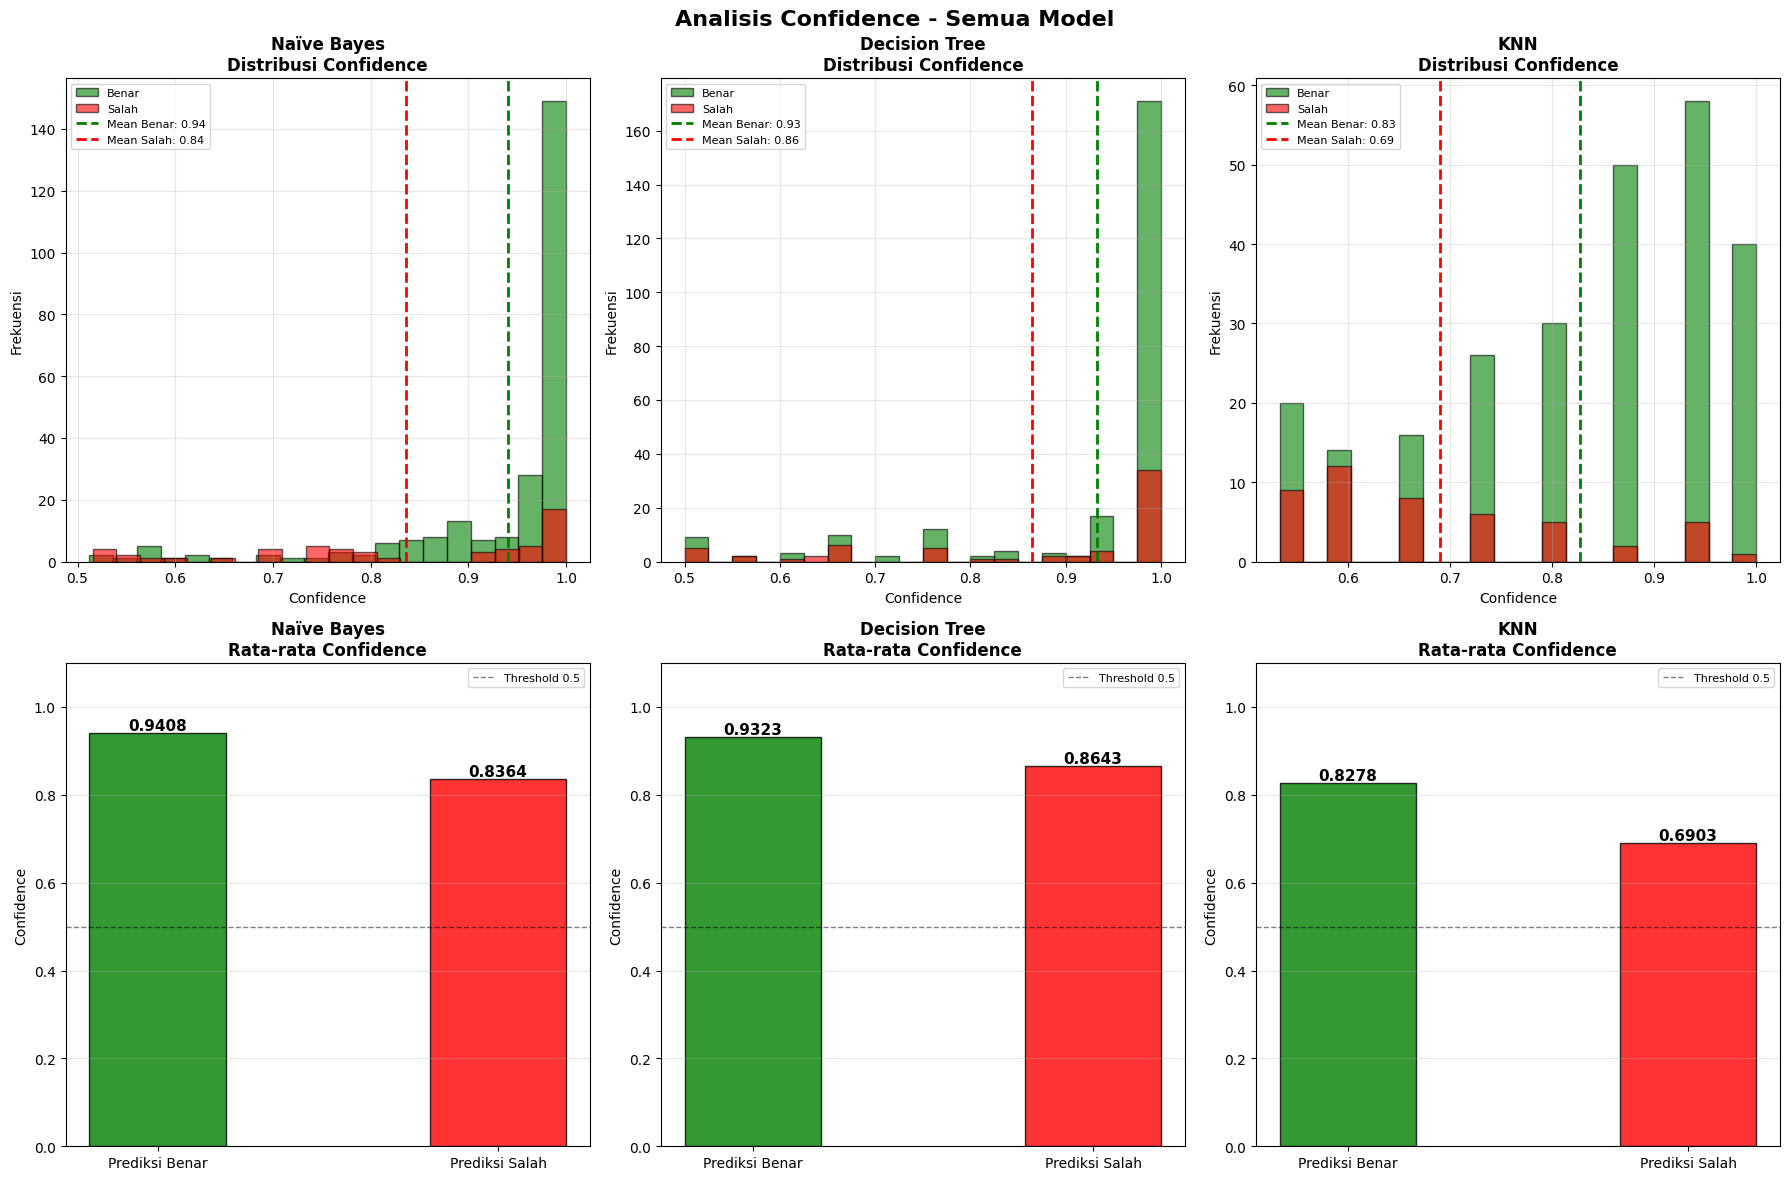

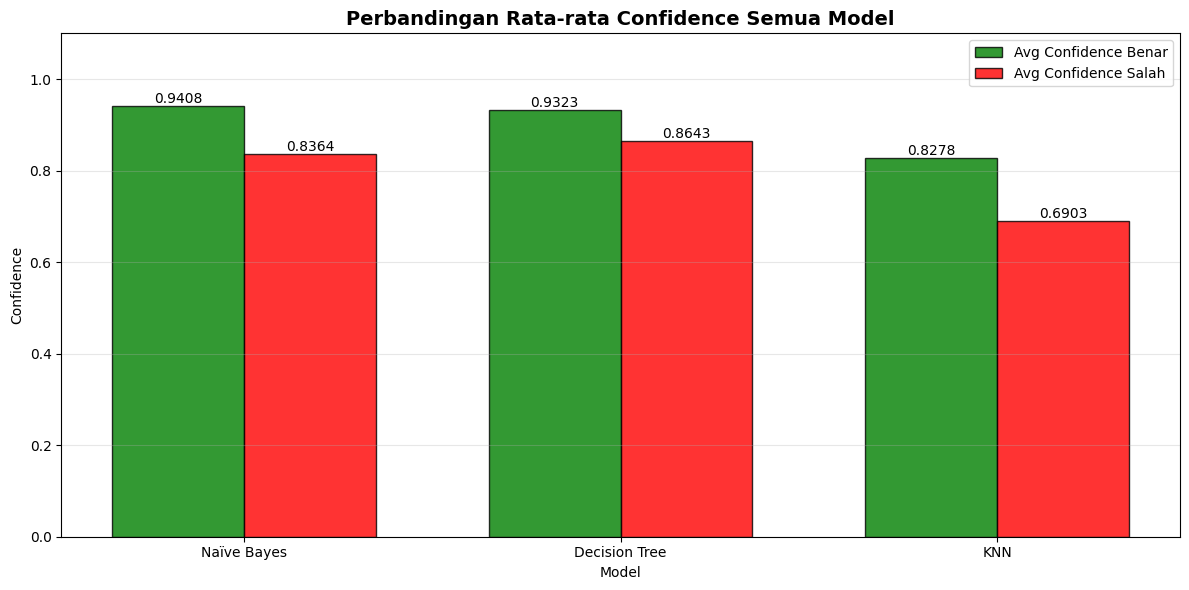

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Analisis Confidence - Semua Model', 
             fontsize=16, fontweight='bold')

configs = [
    (nb_pred,  nb_proba,  'Naïve Bayes'),
    (dt_pred,  dt_proba,  'Decision Tree'),
    (knn_pred, knn_proba, 'KNN')
]

for i, (pred, proba, title) in enumerate(configs):
    conf    = proba.max(axis=1)
    correct = (y.values == pred)

    # ── Baris 1: Histogram Confidence ────────────────
    ax1 = axes[0, i]
    ax1.hist(conf[correct],  bins=20, alpha=0.6, 
             color='green', label='Benar', edgecolor='black')
    ax1.hist(conf[~correct], bins=20, alpha=0.6, 
             color='red',   label='Salah', edgecolor='black')
    ax1.axvline(conf[correct].mean(),  color='green', 
                linestyle='--', linewidth=2,
                label=f'Mean Benar: {conf[correct].mean():.2f}')
    ax1.axvline(conf[~correct].mean(), color='red',   
                linestyle='--', linewidth=2,
                label=f'Mean Salah: {conf[~correct].mean():.2f}')
    ax1.set_title(f'{title}\nDistribusi Confidence', 
                  fontsize=12, fontweight='bold')
    ax1.set_xlabel('Confidence')
    ax1.set_ylabel('Frekuensi')
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3)

    # ── Baris 2: Bar Chart Avg Confidence ────────────
    ax2 = axes[1, i]
    categories = ['Prediksi Benar', 'Prediksi Salah']
    values     = [conf[correct].mean(), conf[~correct].mean()]
    colors     = ['green', 'red']
    
    bars = ax2.bar(categories, values, color=colors, 
                   edgecolor='black', width=0.4, alpha=0.8)
    ax2.set_title(f'{title}\nRata-rata Confidence', 
                  fontsize=12, fontweight='bold')
    ax2.set_ylabel('Confidence')
    ax2.set_ylim(0, 1.1)
    ax2.axhline(y=0.5, color='black', linestyle='--', 
                linewidth=1, alpha=0.5, label='Threshold 0.5')
    ax2.legend(fontsize=8)
    ax2.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        ax2.annotate(f'{bar.get_height():.4f}',
                    xy=(bar.get_x() + bar.get_width()/2, 
                        bar.get_height()),
                    ha='center', va='bottom', 
                    fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Visualisasi Perbandingan Semua Model ──────────────
fig, ax = plt.subplots(figsize=(12, 6))

models    = ['Naïve Bayes', 'Decision Tree', 'KNN']
conf_benar= [nb_cc,  dt_cc,  knn_cc]
conf_salah= [nb_cw,  dt_cw,  knn_cw]

x     = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, conf_benar, width,
               label='Avg Confidence Benar',
               color='green', edgecolor='black', alpha=0.8)
bars2 = ax.bar(x + width/2, conf_salah, width,
               label='Avg Confidence Salah',
               color='red', edgecolor='black', alpha=0.8)

ax.set_title('Perbandingan Rata-rata Confidence Semua Model',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Confidence')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.4f}',
                xy=(bar.get_x() + bar.get_width()/2,
                    bar.get_height()),
                ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.4f}',
                xy=(bar.get_x() + bar.get_width()/2,
                    bar.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Kesimpulan

Penelitian ini telah berhasil mengimplementasikan dan membandingkan tiga 
algoritma *machine learning* yaitu Decision Tree, Naïve Bayes, dan 
K-Nearest Neighbors untuk klasifikasi penyakit jantung menggunakan 
Heart Disease Dataset dari Kaggle/UCI Machine Learning Repository.

---

### 6.1 Rangkuman Hasil Eksperimen

Berdasarkan hasil eksperimen yang telah dilakukan, diperoleh rangkuman 
performa ketiga model sebagai berikut:

| Model | CV Accuracy | Accuracy | Precision | Recall | F1-Score |
|-------|-------------|----------|-----------|--------|----------|
| Naïve Bayes | 81.80% | 82.00% | 0.81 | 0.87 | 0.84 |
| Decision Tree | 78.46% | 78.00% | 0.78 | 0.84 | 0.81 |
| KNN | 84.13% | 84.00% | 0.81 | 0.92 | 0.86 |

---

### 6.2 Temuan Utama

Berdasarkan hasil eksperimen, diperoleh temuan utama sebagai berikut:

1. **K-Nearest Neighbors (KNN) merupakan model terbaik** dengan CV 
   Accuracy sebesar 84.13%, Recall 92%, dan F1-Score 0.86. Model ini 
   unggul dalam mendeteksi pasien sakit jantung dibandingkan dua model 
   lainnya.

2. **Naïve Bayes menempati posisi kedua** dengan CV Accuracy 81.80% 
   dan F1-Score 0.84. Meskipun lebih sederhana dari KNN, Naïve Bayes 
   tetap memberikan performa yang kompetitif dan waktu komputasi yang 
   lebih cepat.

3. **Decision Tree memberikan performa terendah** dengan CV Accuracy 
   78.46% dan F1-Score 0.81. Hal ini kemungkinan disebabkan oleh 
   keterbatasan jumlah data setelah preprocessing (302 baris) yang 
   kurang optimal untuk algoritma berbasis pohon keputusan.

4. **Hasil analisis SHAP** menunjukkan bahwa fitur klinis yang paling 
   berpengaruh terhadap prediksi penyakit jantung adalah jenis kelamin 
   (*sex*), thalassemia (*thal*), tipe nyeri dada (*cp*), jumlah 
   pembuluh darah (*ca*), dan angina akibat olahraga (*exang*). 
   Menariknya, kolesterol (*chol*) yang sering dianggap faktor utama 
   penyakit jantung justru memberikan pengaruh paling kecil pada model.

5. **Analisis confidence** menunjukkan bahwa KNN memiliki selisih 
   confidence terbesar antara prediksi benar dan salah, menandakan 
   model ini paling konsisten dalam memberikan confidence yang tinggi 
   saat prediksinya benar.

---

### 6.3 Rekomendasi

Berdasarkan temuan penelitian ini, dirumuskan beberapa rekomendasi 
sebagai berikut:

1. **Penggunaan Model:** K-Nearest Neighbors direkomendasikan sebagai 
   model utama untuk klasifikasi penyakit jantung berdasarkan dataset 
   ini, khususnya karena nilai Recall yang tinggi (92%) yang sangat 
   penting dalam konteks medis untuk meminimalkan kasus pasien sakit 
   yang tidak terdeteksi.

2. **Pengembangan Dataset:** Disarankan untuk menggunakan dataset yang 
   lebih besar dan beragam untuk meningkatkan generalisasi model, 
   mengingat jumlah data setelah preprocessing hanya 302 baris.

3. **Perhatian Fitur Klinis:** Tenaga medis disarankan untuk lebih 
   memperhatikan fitur jenis kelamin, thalassemia, dan tipe nyeri dada 
   sebagai indikator utama dalam deteksi dini penyakit jantung 
   berdasarkan hasil analisis SHAP.

4. **Pengembangan Lanjutan:** Untuk penelitian selanjutnya, disarankan 
   untuk mengeksplorasi algoritma ensemble seperti Random Forest atau 
   Gradient Boosting yang berpotensi memberikan performa lebih tinggi, 
   serta menerapkan teknik *feature selection* untuk mengoptimalkan 
   fitur yang digunakan.

KESIMPULAN — PERBANDINGAN AKHIR SEMUA MODEL

Tabel Perbandingan Final:


,Model,CV Accuracy,Accuracy,Precision,Recall,F1-Score,Conf Benar,Conf Salah
1,KNN,0.8413,0.8411,0.8118,0.9207,0.8629,0.8278,0.6903
2,Naïve Bayes,0.8180,0.8179,0.8114,0.8659,0.8378,0.9408,0.8364
3,Decision Tree,0.7846,0.7848,0.7829,0.8354,0.8083,0.9323,0.8643


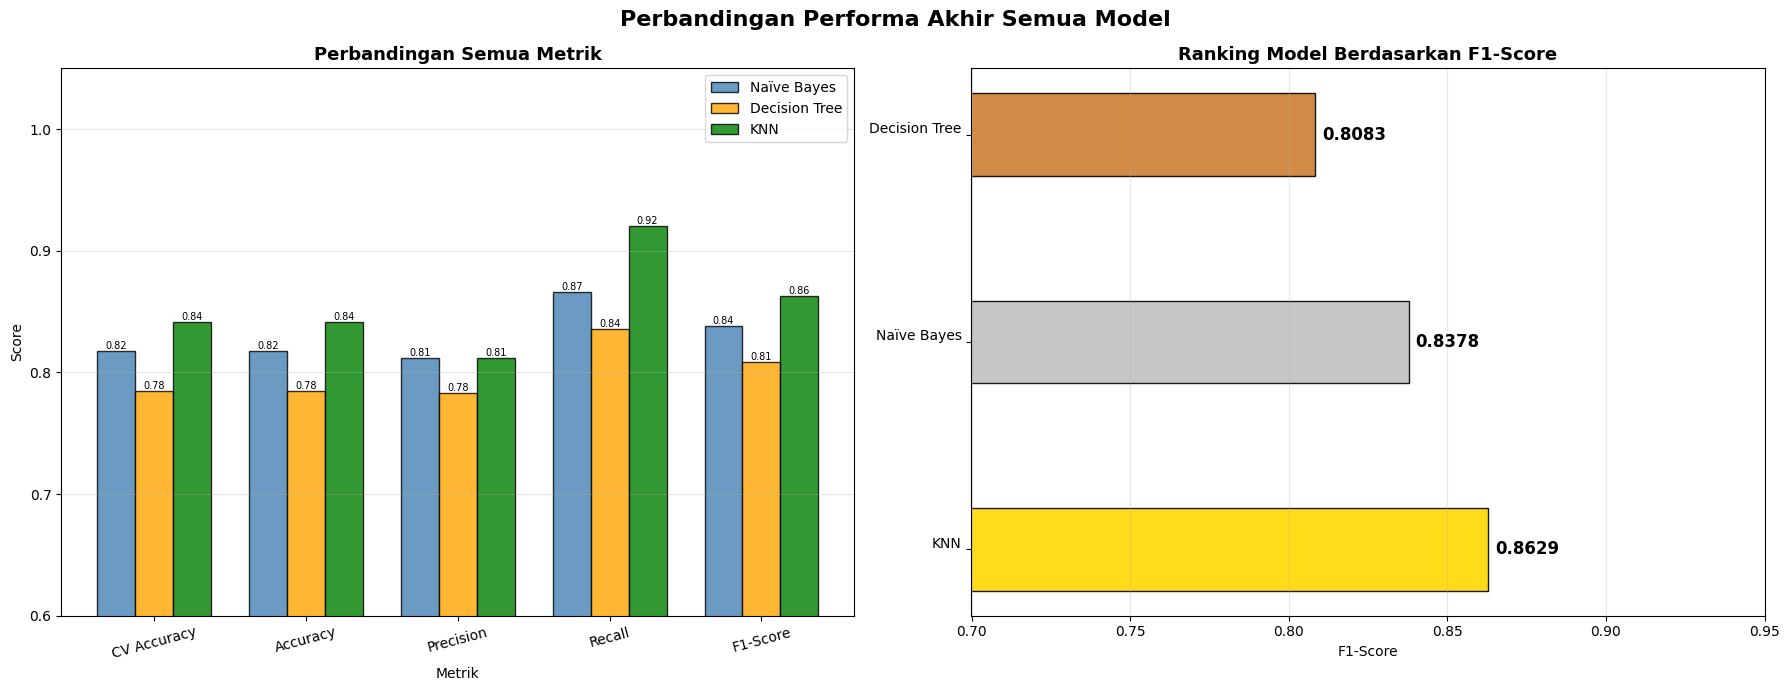


KESIMPULAN FINAL

 Model Terbaik    : KNN
   CV Accuracy      : 0.8413 (84.13%)
   Accuracy         : 0.8411
   Precision        : 0.8118
   Recall           : 0.9207
   F1-Score         : 0.8629
   Conf Benar       : 0.8278
   Conf Salah       : 0.6903

🔍 Fitur Terpenting (SHAP):
   1. sex     (0.0770)
   2. thal    (0.0688)
   3. cp      (0.0651)
   4. ca      (0.0619)
   5. exang   (0.0560)

 Rekomendasi:
   KNN dengan n_neighbors=15, metric=euclidean,
   weights=uniform direkomendasikan sebagai model
   terbaik untuk deteksi dini penyakit jantung
   berdasarkan dataset ini.



In [37]:
print("=" * 55)
print("KESIMPULAN — PERBANDINGAN AKHIR SEMUA MODEL")
print("=" * 55)

# ── Tabel Perbandingan Final ──────────────────────────
final_results = pd.DataFrame({
    'Model'        : ['Naïve Bayes', 'Decision Tree', 'KNN'],
    'CV Accuracy'  : [nb_grid.best_score_, 
                      dt_grid.best_score_, 
                      knn_grid.best_score_],
    'Accuracy'     : [accuracy_score(y, nb_pred),
                      accuracy_score(y, dt_pred),
                      accuracy_score(y, knn_pred)],
    'Precision'    : [precision_score(y, nb_pred),
                      precision_score(y, dt_pred),
                      precision_score(y, knn_pred)],
    'Recall'       : [recall_score(y, nb_pred),
                      recall_score(y, dt_pred),
                      recall_score(y, knn_pred)],
    'F1-Score'     : [f1_score(y, nb_pred),
                      f1_score(y, dt_pred),
                      f1_score(y, knn_pred)],
    'Conf Benar'   : [nb_cc,  dt_cc,  knn_cc],
    'Conf Salah'   : [nb_cw,  dt_cw,  knn_cw]
})

final_results = final_results.sort_values(
    'F1-Score', ascending=False).reset_index(drop=True)
final_results.index += 1
print("\nTabel Perbandingan Final:")
display(final_results.round(4))

# ── Visualisasi Radar Chart ───────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Perbandingan Performa Akhir Semua Model',
             fontsize=16, fontweight='bold')

# Bar Chart Semua Metrik
ax1 = axes[0]
metrics    = ['CV Accuracy', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
nb_scores  = [nb_grid.best_score_,
              accuracy_score(y, nb_pred),
              precision_score(y, nb_pred),
              recall_score(y, nb_pred),
              f1_score(y, nb_pred)]
dt_scores  = [dt_grid.best_score_,
              accuracy_score(y, dt_pred),
              precision_score(y, dt_pred),
              recall_score(y, dt_pred),
              f1_score(y, dt_pred)]
knn_scores = [knn_grid.best_score_,
              accuracy_score(y, knn_pred),
              precision_score(y, knn_pred),
              recall_score(y, knn_pred),
              f1_score(y, knn_pred)]

x     = np.arange(len(metrics))
width = 0.25

b1 = ax1.bar(x - width,   nb_scores,  width, label='Naïve Bayes',
             color='steelblue', edgecolor='black', alpha=0.8)
b2 = ax1.bar(x,            dt_scores,  width, label='Decision Tree',
             color='orange',    edgecolor='black', alpha=0.8)
b3 = ax1.bar(x + width,   knn_scores, width, label='KNN',
             color='green',     edgecolor='black', alpha=0.8)

ax1.set_title('Perbandingan Semua Metrik', 
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Metrik')
ax1.set_ylabel('Score')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, rotation=15)
ax1.set_ylim(0.6, 1.05)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax1.annotate(f'{bar.get_height():.2f}',
                    xy=(bar.get_x() + bar.get_width()/2,
                        bar.get_height()),
                    ha='center', va='bottom', fontsize=7)

# Ranking Model
ax2 = axes[1]
models_rank = ['KNN\n', 'Naïve Bayes\n', 'Decision Tree\n']
f1_scores   = [f1_score(y, knn_pred),
               f1_score(y, nb_pred),
               f1_score(y, dt_pred)]
colors_rank = ['gold', 'silver', '#cd7f32']

bars = ax2.barh(models_rank, f1_scores,
                color=colors_rank, edgecolor='black',
                height=0.4, alpha=0.9)
ax2.set_title('Ranking Model Berdasarkan F1-Score',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('F1-Score')
ax2.set_xlim(0.7, 0.95)
ax2.grid(axis='x', alpha=0.3)

for bar in bars:
    ax2.annotate(f'{bar.get_width():.4f}',
                xy=(bar.get_width(), bar.get_y() + bar.get_height()/2),
                ha='left', va='center', fontsize=12,
                fontweight='bold', xytext=(5, 0),
                textcoords='offset points')

plt.tight_layout()
plt.show()

# ── Cetak Kesimpulan Final ────────────────────────────
print("\n" + "=" * 55)
print("KESIMPULAN FINAL")
print("=" * 55)
print(f"""
 Model Terbaik    : KNN
   CV Accuracy      : {knn_grid.best_score_:.4f} ({knn_grid.best_score_*100:.2f}%)
   Accuracy         : {accuracy_score(y, knn_pred):.4f}
   Precision        : {precision_score(y, knn_pred):.4f}
   Recall           : {recall_score(y, knn_pred):.4f}
   F1-Score         : {f1_score(y, knn_pred):.4f}
   Conf Benar       : {knn_cc:.4f}
   Conf Salah       : {knn_cw:.4f}

🔍 Fitur Terpenting (SHAP):
   1. sex     (0.0770)
   2. thal    (0.0688)
   3. cp      (0.0651)
   4. ca      (0.0619)
   5. exang   (0.0560)

 Rekomendasi:
   KNN dengan n_neighbors=15, metric=euclidean,
   weights=uniform direkomendasikan sebagai model
   terbaik untuk deteksi dini penyakit jantung
   berdasarkan dataset ini.
""")